# Bytes uploaded: `@wasm` image preprocessing in the browser vs the naive upload

**What this measures (plan §2/§9 positioning: bandwidth + server CPU per request; no model, no GPU).**
A Gradio app where a photo is box-downscaled to at most 512 px **in the browser tab by a `@wasm`-compiled
Python kernel** (`kernels.py::downscale_box`, compiled by `pyths` to WASM, run through the pythscribe list-buffer
FFI shim) and only the small JPEG is uploaded — against the **naive control in the same app**: the stock
`gr.File` uploads the original untouched and the server resizes it with Pillow.

**How it is measured.** `metrics_lib.collect` launches the real app (`app.py`) and drives **both panels with a
real headless Chromium** (Playwright) for every committed test image. Every byte count in the table is what the
**server's ASGI byte meter counted on its side of the socket** for that upload (`upload_bytes`), never a client
claim. The server also reports `python_calls` (how often the kernel's Python body ran on the server since the
dispatch — 0 on the browser path) and the CRC-32 of the resized pixels.

**Reproduce.** From a clone: `pip install -e .[gradio,test] && pip install -e pythscribe/gradio/wasm_function`,
`python -m playwright install chromium`, then run this notebook top to bottom (`NB_REPEATS` env var, default 3).
Nothing below is hardcoded: change the images in `test_images/` and the table changes (`tests/pythscribe/test_notebook_derivation.py`
asserts exactly that).

In [1]:
import json, os, platform, subprocess, sys, time
from pathlib import Path
import numpy as np
HERE = Path.cwd() if (Path.cwd() / "app.py").is_file() else Path(__file__).resolve().parent  # noqa
sys.path.insert(0, str(HERE))
import metrics_lib as M
import reference as R
import pythscribe, gradio, PIL

REPEATS = int(os.environ.get("NB_REPEATS", "3"))
MAX_DIM = 512
np.random.seed(0)  # (nothing random is used; the image set is committed and manifest-pinned)
images = M.committed_images()
print("python", platform.python_version(), "| gradio", gradio.__version__, "| pythscribe", pythscribe.__version__,
      "compiler pin", pythscribe.COMPILER_VERSION, pythscribe.COMPILER_COMMIT[:12], "| Pillow", PIL.__version__, "| numpy", np.__version__)
print("repo commit:", subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True, cwd=HERE).stdout.strip() or "n/a")
print("repeats per image:", REPEATS)
for p in images:
    m = json.loads((HERE / "test_images" / "manifest.json").read_text())[p.name]
    print(f"  {p.name}: {m['w']}x{m['h']} = {m['w']*m['h']/1e6:.1f} MP, {m['bytes']:,} B, sha256 {m['sha256'][:12]}")

C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python 3.14.7 | gradio 6.26.0 | pythscribe 0.2.5a0 compiler pin 0.2.4 7aac7cf16919 | Pillow 12.3.0 | numpy 2.5.2
repo commit: fd5a94de
repeats per image: 3
  photo_640x480.jpg: 640x480 = 0.3 MP, 71,009 B, sha256 fb3aa190ed5c
  photo_1600x1200.jpg: 1600x1200 = 1.9 MP, 411,850 B, sha256 15805967cbf1
  photo_4000x3000.jpg: 4000x3000 = 12.0 MP, 2,494,311 B, sha256 178ee12bf1d0


## 1. Measure both paths in a real browser against the real app
One app, one tab, one server-side meter; per image: client panel (WASM in-tab → small JPEG uploaded), then the naive panel (original uploaded, Pillow on the server).

In [2]:
t0 = time.time()
records = M.collect(images, repeats=REPEATS)
print(f"{len(records)} records in {time.time()-t0:.0f} s")
(HERE / "metrics_records.json").write_text(json.dumps(records, indent=1), encoding="utf-8")
for r in records[:2]:
    print({k: r[k] for k in ("image", "mode", "path", "python_calls", "consistent", "upload_bytes", "join_bytes", "wire_bytes", "upload_measured", "file_bytes", "checksum") if k in r},
          "| client says:", {k: r["client"][k] for k in ("in_w", "in_h", "scale", "checksum", "wasm_fetched")} if "client" in r else "-")

18 records in 11 s
{'image': 'photo_640x480.jpg', 'mode': 'client', 'path': 'browser-wasm', 'python_calls': 0, 'consistent': True, 'upload_bytes': 10518, 'join_bytes': 2290, 'wire_bytes': 12808, 'upload_measured': True, 'file_bytes': 10314} | client says: {'in_w': 640, 'in_h': 480, 'scale': 2, 'checksum': 4066014092, 'wasm_fetched': 2}
{'image': 'photo_640x480.jpg', 'mode': 'naive', 'path': 'server-pillow', 'python_calls': 0, 'upload_bytes': 71201, 'join_bytes': 492, 'wire_bytes': 71693, 'upload_measured': True, 'file_bytes': 71009, 'checksum': 4066014092} | client says: -


## 2. The same kernel in CPython (what the server would pay if this resize ran server-side in Python)
The naive panel's Pillow timings are the *realistic* server baseline; this row is the apples-to-apples one:
the very function that ran in WASM in the tab, run by CPython on this machine.

In [3]:
cpython = M.cpython_kernel_ms(images, MAX_DIM)
for k, v in cpython.items():
    print(f"  {k}: {v['cpython_kernel_ms']:.0f} ms wall, exact vs reference: {v['exact_vs_reference']}")

  photo_640x480.jpg: 107 ms wall, exact vs reference: True
  photo_1600x1200.jpg: 522 ms wall, exact vs reference: True
  photo_4000x3000.jpg: 2695 ms wall, exact vs reference: True


## 3. Summary table (computed from the records above)

In [4]:
summary = M.summarize(records, cpython)
(HERE / "metrics_summary.json").write_text(json.dumps(summary, indent=1), encoding="utf-8")
from IPython.display import Markdown, display
display(Markdown(M.format_table(summary)))
a = summary["aggregate"]
print(f"\nAggregate over {a['images']} images (client path: {a['client_paths']}): {a['naive_upload_bytes_total']:,.0f} B naive -> {a['client_upload_bytes_total']:,.0f} B client = "
      f"{a['reduction_x']:.1f}x fewer upload bytes ({a['reduction_pct']:.1f}% reduction); on the wire incl. the event JSON: "
      f"{a['naive_wire_bytes_total']:,.0f} -> {a['client_wire_bytes_total']:,.0f} B = {a['wire_reduction_x']:.1f}x; server-side resize no longer run: "
      f"{a['server_resize_ms_saved_total']:.1f} ms (Pillow) / {a.get('cpython_kernel_ms_total', 0):.0f} ms (same kernel in CPython); "
      f"server CPU per request set: {a['server_cpu_ms_naive_total']:.0f} ms -> {a['server_cpu_ms_client_total']:.0f} ms")

| image | in -> out (scale) | client path (server-decided) | naive upload B | client upload B | reduction | naive wire B (upload+event) | client wire B | wire reduction | server resize ms (Pillow, naive) | server CPU ms naive -> client | WASM call ms (tab) | same kernel in CPython ms |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| photo_640x480.jpg | 640x480 -> 320x240 (2) | browser-wasm | 71,201 | 10,518 | 6.8x (85.2%) | 71,693 | 12,777 | 5.6x | 0.9 | 15.6 -> 0.0 | 8.0 | 107 |
| photo_1600x1200.jpg | 1600x1200 -> 400x300 (4) | browser-wasm | 412,044 | 10,886 | 37.9x (97.4%) | 412,543 | 13,175 | 31.3x | 4.6 | 15.6 -> 0.0 | 27.3 | 522 |
| photo_4000x3000.jpg | 4000x3000 -> 500x375 (8) | browser-wasm | 2,494,505 | 12,109 | 206.0x (99.5%) | 2,495,005 | 14,428 | 172.9x | 28.0 | 109.4 -> 0.0 | 231.6 | 2695 |
| **all 3** | | browser-wasm | 2,977,750 | 33,513 | **88.9x (98.9%)** | 2,979,241 | 40,380 | **73.8x** | 33.5 | 140.6 -> 0.0 | | 3324 |


Aggregate over 3 images (client path: browser-wasm): 2,977,750 B naive -> 33,513 B client = 88.9x fewer upload bytes (98.9% reduction); on the wire incl. the event JSON: 2,979,241 -> 40,380 B = 73.8x; server-side resize no longer run: 33.5 ms (Pillow) / 3324 ms (same kernel in CPython); server CPU per request set: 141 ms -> 0 ms


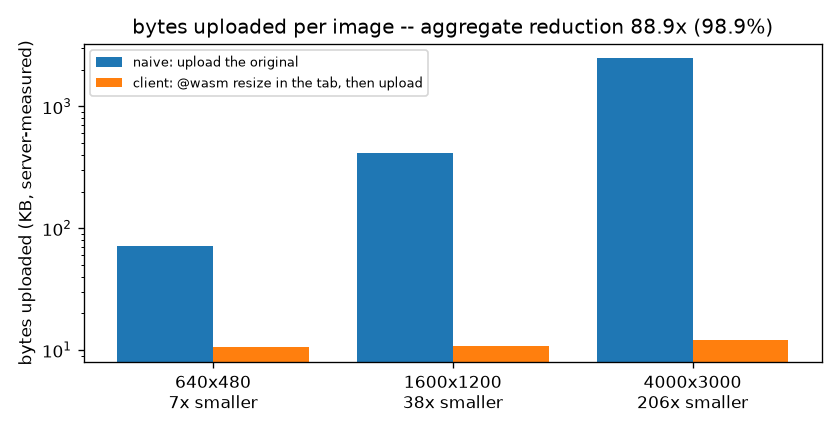

In [5]:
from IPython.display import Image as IPImage
png = M.plot(summary, HERE / "bytes_reduction.png")
IPImage(filename=str(png))

## 4. Anti-vacuity checks (each would go RED if the claim were hollow)
* the client path really ran in WASM in the tab: `path=browser-wasm`, server-side `python_calls == 0`, a `.wasm` was fetched, and the
  checksum of the WASM output equals the server's NumPy reference on the same file;
* the reduction is measured against a real control: naive bytes ≥ file size (the meter saw the whole original), client bytes ≪;
* **negative control**: the same app WITHOUT the artifact (its client panel uploads the original and the server runs the
  Python fallback) is exactly what a "client that secretly uploads the full image" looks like on the meter — the reduction
  assertion must FAIL on it;
* the table is a function of its inputs: dropping an image changes the aggregate.

In [6]:
import shutil, tempfile
for r in records:
    if r["mode"] == "client":
        # server-decided path + server-derived markers; the browser's story is under r["client"] and only COMPARED
        assert r["path"] == "browser-wasm" and r["python_calls"] == 0 and r["consistent"] is True, r
        assert r["client"]["wasm_fetched"] >= 1 and "downscale_box" in r["client"]["wasm_exports"], r["client"]
        assert r["upload_measured"] and r["upload_bytes"] >= r["file_bytes"]
    else:
        assert r["path"] == "server-pillow" and r["upload_measured"]
        assert r["upload_bytes"] >= (HERE / "test_images" / r["image"]).stat().st_size
for row in summary["rows"]:
    assert row["reduction_x"] > 5, row
# the browser's CRC of the WASM output vs the server's NumPy reference on the same JPEG: equal here means Chromium
# and Pillow decoded the JPEG identically. JPEG decoders may legitimately differ by an LSB across libjpeg builds,
# so this is REPORTED, not asserted -- the exact in-browser correctness gate uses lossless PNG (tests A1/A4).
mism = [r["image"] for r in summary["rows"] if not r["checksum_match"]]
print("client path markers + measured reduction: OK on", len(summary["rows"]), "images;",
      "browser CRC == server reference on all" if not mism else f"decoder LSB difference on {mism} (expected across libjpeg builds)")
tick = records[0].get("cpu_timer_resolution_ms")
print("server CPU timer resolution:", f"{tick:.3f} ms per tick" if tick is not None else "could not be calibrated within 0.25 s (reported as None, never a made-up 0)",
      "-- a 0.0 CPU reading means 'below one tick', not zero")

# negative control: an app copy without the artifacts -> the client panel uploads the ORIGINAL and the
# server runs the Python fallback -> (a) summarize REFUSES to tabulate it as the '@wasm in the tab' arm,
# (b) tabulated explicitly as a fallback, the reduction assertion goes RED
tmp = Path(tempfile.mkdtemp(prefix="m1_noartifact_"))
try:
    shutil.copytree(HERE, tmp / "app", ignore=shutil.ignore_patterns("__pycache__", "_app.log", "metrics*", "*.ipynb", "test_images", "__pythscribe__"))
    neg = M.collect(images[:1], app_dir=tmp / "app")
    assert neg[0]["path"] == "python-fallback" and neg[0]["python_calls"] == 1, neg[0]
    try:
        M.summarize(neg)
        raise SystemExit("summarize accepted a fallback run as the in-tab arm -- the label would lie")
    except ValueError as e:
        print("negative control (a): summarize refused the fallback run as the in-tab arm ->", e)
    row = M.summarize(neg, allow_fallback=True)["rows"][0]
    assert row["client_path"] == "python-fallback" and row["reduction_x"] < 1.05, row
    try:
        assert row["reduction_x"] > 5, "reduction not present"
        raise SystemExit("the negative control did NOT go red -- the reduction assertion is vacuous")
    except AssertionError as e:
        print("negative control (b) (client uploads the ORIGINAL, python-fallback):", f"reduction {row['reduction_x']:.2f}x ->", "RED as required:", e)
finally:
    shutil.rmtree(tmp, ignore_errors=True)

# derivation: the table is a function of the records
sub = M.summarize([r for r in records if r["image"] != images[-1].name], cpython)
assert sub["aggregate"]["reduction_x"] != summary["aggregate"]["reduction_x"]
print("derivation: aggregate with the largest image dropped:", f"{sub['aggregate']['reduction_x']:.1f}x vs {summary['aggregate']['reduction_x']:.1f}x -> the numbers are computed, not constants")

client path markers + measured reduction: OK on 3 images; browser CRC == server reference on all
server CPU timer resolution: 15.625 ms per tick -- a 0.0 CPU reading means 'below one tick', not zero


negative control (a): summarize refused the fallback run as the in-tab arm -> photo_640x480.jpg: client records did not all run in the tab (server-decided path ['python-fallback']); pass allow_fallback=True to tabulate a fallback run AS a fallback
negative control (b) (client uploads the ORIGINAL, python-fallback): reduction 1.00x -> RED as required: reduction not present
derivation: aggregate with the largest image dropped: 22.6x vs 88.9x -> the numbers are computed, not constants


## 5. Throughput (plan §9) — recipe, no fabricated number

In [7]:
print(M.throughput_recipe(summary))

Throughput (requests/hour on a fixed tier) is NOT measured in this notebook -- no fabricated number.
First-order model: per request the server spends  t = bytes / link_rate + server_cpu.
  naive  (largest image): 2,494,505 B + 109 ms CPU
  client (largest image): 12,109 B + 0 ms CPU
  => on a link where the upload dominates, requests/hour scales with the bytes ratio (206x for that image; 88.9x aggregate).
Recipe (run it against a deployed Space, both panels, same tier):
  k6 run --vus 20 --duration 10m upload.js   # POST the original to /gradio_api/upload + /gradio_api/queue/join (naive)
  k6 run --vus 20 --duration 10m upload.js -e MODE=client   # POST the pre-resized JPEG (what the tab would send)
  compare http_reqs/s and p95 latency; the CPU side is visible in the Space's metrics.


## Reading the numbers
* **Bytes uploaded** is the headline: a real upload from a real tab, counted on the server. The ratio depends on the source
  (a smooth synthetic JPEG at q=90 compresses better than a noisy phone photo, so a 12 MP camera JPEG typically starts larger and
  the ratio grows).
* **Server CPU saved** has two honest readings: the Pillow resize the naive path actually runs (small, C-implemented), and the same
  Python kernel run by CPython (what a pure-Python server resize would cost). Both are measured above, neither is the model.
* **What did not move**: the model, the GPU, the queue. This is preprocessing around the model, which is the plan's claim and nothing more.